In [1]:
import tensorflow as tf

# Check for GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Available: {len(gpus)}")

if gpus:
    for gpu in gpus:
        print(f"Device Name: {gpu.name}")
    print("\n✅ KokoAlert is officially GPU-accelerated!")
else:
    print("\n❌ Still on CPU. We might need to check your WSL LD_LIBRARY_PATH.")

2026-05-06 14:53:34.733016: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-06 14:53:34.853737: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-06 14:53:34.889553: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-06 14:53:35.106532: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-06 14:53:36.831011: W tensorflow/compiler/tf2

GPUs Available: 1
Device Name: /physical_device:GPU:0

✅ KokoAlert is officially GPU-accelerated!


I0000 00:00:1778079220.539496    4683 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778079220.799370    4683 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778079220.799454    4683 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import os
os.chdir('/home/opokuml/kokoalert')

import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from src.preprocess import process_dataset_split, file_to_spectrograms
from src.anomaly_detector import (
    build_classifier, compile_classifier,
    get_training_callbacks, compute_window_probabilities,
    save_classifier
)
from src.config import MODEL_DIR

print("All imports OK")

All imports OK


In [3]:
# Cell 2 — Load and preprocess healthy training data

from src.preprocess import process_dataset_split

print("Loading healthy training data...")
X_healthy, y_healthy = process_dataset_split(
    folder="data/raw/bowen/healthy",
    label=0
)

print(f"\nHealthy windows loaded: {X_healthy.shape}")
print(f"Data type: {X_healthy.dtype}")
print(f"Value range: {X_healthy.min():.3f} to {X_healthy.max():.3f}")

Loading healthy training data...
  Processed 20/139 clips (639 windows so far)
  Processed 40/139 clips (901 windows so far)
  Processed 60/139 clips (1108 windows so far)
  Processed 80/139 clips (1322 windows so far)
  Processed 100/139 clips (1463 windows so far)
  Processed 120/139 clips (1839 windows so far)

Healthy windows loaded: (2051, 128, 157, 1)
Data type: float32
Value range: -80.000 to 0.000


In [ ]:
autoencoder.summary()

In [4]:
# Cell 3 — Min-max normalisation + save params

import json
import os

# Compute normalisation params FROM HEALTHY TRAINING DATA ONLY
# Never compute from sick data — that would leak information about
# the anomaly distribution into your normalisation and bias the threshold
X_min = float(X_healthy.min())
X_max = float(X_healthy.max())

print(f"Before normalisation: {X_min:.3f} to {X_max:.3f}")

# Normalise to [0, 1]
X_train = (X_healthy - X_min) / (X_max - X_min + 1e-8)

print(f"After normalisation:  {X_train.min():.3f} to {X_train.max():.3f}")
print(f"Shape: {X_train.shape}")

# Save normalisation params to disk
# These MUST be applied identically at inference time
# If you normalise differently during inference, reconstruction errors
# will be wrong and your threshold will not work
os.makedirs("models", exist_ok=True)
norm_params = {"min": X_min, "max": X_max}

with open("models/normalization_params.json", "w") as f:
    json.dump(norm_params, f, indent=2)

print(f"\nNormalisation params saved:")
print(f"  min: {X_min}")
print(f"  max: {X_max}")

Before normalisation: -80.000 to 0.000
After normalisation:  0.000 to 1.000
Shape: (2051, 128, 157, 1)

Normalisation params saved:
  min: -80.0
  max: 1.9073486328125e-06


In [5]:
# Cell 4 — Augmentation + train/validation split

from sklearn.model_selection import train_test_split

def augment_batch(X: np.ndarray) -> np.ndarray:
    """
    Apply 4 augmentations to every spectrogram window.
    Returns the augmented samples only — we concatenate with
    originals after.

    Why augment spectrograms not raw audio:
    Operating on spectrograms is faster and the augmentations
    map directly to real-world recording variations:

    - Time masking → bird briefly moves away from microphone
    - Frequency masking → different house acoustics absorb
      certain frequencies differently
    - Gaussian noise → different phone microphone quality
    - Amplitude shift → farmer holds phone at different distances

    We only augment training data, never validation.
    Augmenting validation data would give you falsely optimistic
    metrics — you'd be validating on transformed versions of
    training samples.
    """
    augmented = []

    for spec in X:
        s = spec[:, :, 0]  # Remove channel dim for manipulation

        # Augmentation 1 — Time masking
        aug = s.copy()
        t_start = np.random.randint(0, s.shape[1] - 20)
        t_width = np.random.randint(5, 20)
        aug[:, t_start:t_start + t_width] = s.min()
        augmented.append(aug[:, :, np.newaxis])

        # Augmentation 2 — Frequency masking
        aug = s.copy()
        f_start = np.random.randint(0, s.shape[0] - 15)
        f_width = np.random.randint(5, 15)
        aug[f_start:f_start + f_width, :] = s.min()
        augmented.append(aug[:, :, np.newaxis])

        # Augmentation 3 — Gaussian noise
        aug = s.copy() + np.random.normal(0, 0.02, s.shape)
        aug = np.clip(aug, 0, 1)  # Keep in [0,1] after adding noise
        augmented.append(aug[:, :, np.newaxis])

        # Augmentation 4 — Amplitude shift
        aug = s.copy() * np.random.uniform(0.85, 1.15)
        aug = np.clip(aug, 0, 1)
        augmented.append(aug[:, :, np.newaxis])

    return np.array(augmented)


# Split BEFORE augmentation
# This is critical — if you augment first then split, augmented
# versions of training samples end up in validation, and your
# val_loss becomes meaningless (model has effectively seen them)
X_train_base, X_val = train_test_split(
    X_train,
    test_size=0.15,
    random_state=42
)

print(f"Base training windows:   {X_train_base.shape[0]}")
print(f"Validation windows:      {X_val.shape[0]}")

# Augment training data only
print("\nAugmenting training data...")
X_augmented = augment_batch(X_train_base)
print(f"Augmented windows:       {X_augmented.shape[0]}")

# Combine originals + augmented
X_train_final = np.concatenate([X_train_base, X_augmented], axis=0)

# Shuffle so augmented versions aren't always grouped together
shuffle_idx = np.random.permutation(len(X_train_final))
X_train_final = X_train_final[shuffle_idx]

print(f"\nFinal training set:      {X_train_final.shape[0]} windows")
print(f"Validation set:          {X_val.shape[0]} windows")
print(f"Augmentation multiplier: {X_train_final.shape[0] / X_train_base.shape[0]:.1f}x")
print(f"\nValue range check:")
print(f"  Train: {X_train_final.min():.3f} to {X_train_final.max():.3f}")
print(f"  Val:   {X_val.min():.3f} to {X_val.max():.3f}")

Base training windows:   1743
Validation windows:      308

Augmenting training data...
Augmented windows:       6972

Final training set:      8715 windows
Validation set:          308 windows
Augmentation multiplier: 5.0x

Value range check:
  Train: 0.000 to 1.000
  Val:   0.000 to 1.000


In [6]:
# Cell 5 — Load sick data, build combined dataset, train classifier

from src.preprocess import process_dataset_split
from src.anomaly_detector import build_classifier, compile_classifier, get_training_callbacks
from sklearn.model_selection import train_test_split

# Load sick data
print("Loading sick training data...")
X_sick_raw, y_sick = process_dataset_split(
    folder="data/raw/bowen/sick",
    label=1
)

# Normalise sick using healthy params — same params, always
X_sick = (X_sick_raw - X_min) / (X_max - X_min + 1e-8)
print(f"Sick windows: {X_sick.shape[0]}")

# Combine healthy and sick
X_all = np.concatenate([X_train, X_sick], axis=0)
y_all = np.concatenate([
    np.zeros(len(X_train)),   # healthy = 0
    np.ones(len(X_sick))      # sick = 1
], axis=0)

print(f"\nCombined dataset: {X_all.shape[0]} windows")
print(f"  Healthy: {int(y_all.sum() == 0)} — "
      f"actually: {int((y_all == 0).sum())}")
print(f"  Sick:    {int((y_all == 1).sum())}")

# Split before augmentation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all,
    test_size=0.15,
    random_state=42,
    stratify=y_all  # preserve class balance in both splits
)

print(f"\nTrain: {len(X_tr)} | Val: {len(X_val)}")
print(f"Train sick ratio: {y_tr.mean():.1%}")
print(f"Val sick ratio:   {y_val.mean():.1%}")

# Augment training data only
print("\nAugmenting training data...")
X_tr_aug = augment_batch(X_tr)

# Build augmented labels — 4 augmentations per sample
y_tr_aug = np.tile(y_tr, 4)

X_train_final = np.concatenate([X_tr, X_tr_aug], axis=0)
y_train_final = np.concatenate([y_tr, y_tr_aug], axis=0)

# Shuffle
idx = np.random.permutation(len(X_train_final))
X_train_final = X_train_final[idx]
y_train_final = y_train_final[idx]

print(f"Final training set: {len(X_train_final)} windows")
print(f"Final val set:      {len(X_val)} windows")

# Build and train
classifier = build_classifier()
classifier = compile_classifier(classifier)
classifier.summary()

print("\nStarting training...\n")

history = classifier.fit(
    X_train_final, y_train_final,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=get_training_callbacks(),
    shuffle=True,
    verbose=1
)

print("\nTraining complete.")

Loading sick training data...
  Processed 20/121 clips (206 windows so far)
  Processed 40/121 clips (450 windows so far)
  Processed 60/121 clips (794 windows so far)
  Processed 80/121 clips (989 windows so far)
  Processed 100/121 clips (1274 windows so far)
  Processed 120/121 clips (1497 windows so far)
Sick windows: 1536

Combined dataset: 3587 windows
  Healthy: 0 — actually: 2051
  Sick:    1536

Train: 3048 | Val: 539
Train sick ratio: 42.8%
Val sick ratio:   42.9%

Augmenting training data...
Final training set: 15240 windows
Final val set:      539 windows


I0000 00:00:1778079340.286639    4683 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778079340.294375    4683 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778079340.294482    4683 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778079340.861155    4683 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778079340.861893    4683 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-06

Model: "koko_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 157, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 155, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 155, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 126, 155, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 76, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 76, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 61, 76, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 31, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 29, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 29, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 29, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 102,145 (399.00 KB)

...


Epoch 7: finished saving model to /home/opokuml/kokoalert/models/classifier_best.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6231 - auc: 0.6424 - loss: 0.6499 - val_accuracy: 0.8015 - val_auc: 0.9970 - val_loss: 0.4433 - learning_rate: 0.0010
Epoch 8/100
476/477 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6185 - auc: 0.6394 - loss: 0.6530
Epoch 8: val_auc did not improve from 0.99702
477/477 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.6239 - auc: 0.6458 - loss: 0.6481 - val_accuracy: 0.5955 - val_auc: 0.9259 - val_loss: 0.5656 - learning_rate: 0.0010
Epoch 9/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6221 - auc: 0.6429 - loss: 0.6497
Epoch 9: val_auc did not improve from 0.99702
477/477 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.6261 - auc: 0.6487 - loss: 0.6463 - val_accuracy: 0.5788 - val_auc: 0.9938 - val_loss: 0.6185 - learning_rate: 0.0010
Epoch 10/100
476/477 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6271 - auc: 0.6498 - loss


Epoch 11: finished saving model to /home/opokuml/kokoalert/models/classifier_best.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.6303 - auc: 0.6551 - loss: 0.6427 - val_accuracy: 0.9759 - val_auc: 0.9977 - val_loss: 0.3693 - learning_rate: 0.0010
Epoch 12/100
476/477 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6282 - auc: 0.6514 - loss: 0.6439
Epoch 12: val_auc did not improve from 0.99771
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.6287 - auc: 0.6513 - loss: 0.6433 - val_accuracy: 0.6475 - val_auc: 0.7320 - val_loss: 0.6519 - learning_rate: 0.0010
Epoch 13/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6328 - auc: 0.6637 - loss: 0.6387
Epoch 13: val_auc did not improve from 0.99771
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6311 - auc: 0.6569 - loss: 0.6406 - val_accuracy: 0.8738 - val_auc: 0.9632 - val_loss: 0.5101 - learning_rate: 0.0010
Epoch 14/100
476/477 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6359 - auc: 0.6570 -


Epoch 14: finished saving model to /home/opokuml/kokoalert/models/classifier_best.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6293 - auc: 0.6559 - loss: 0.6411 - val_accuracy: 0.8479 - val_auc: 0.9996 - val_loss: 0.4051 - learning_rate: 0.0010
Epoch 15/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6281 - auc: 0.6641 - loss: 0.6410
Epoch 15: val_auc did not improve from 0.99959
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.6332 - auc: 0.6626 - loss: 0.6384 - val_accuracy: 0.6790 - val_auc: 0.9991 - val_loss: 0.4306 - learning_rate: 0.0010
Epoch 16/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6358 - auc: 0.6655 - loss: 0.6377
Epoch 16: val_auc did not improve from 0.99959
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6320 - auc: 0.6605 - loss: 0.6394 - val_accuracy: 0.9406 - val_auc: 0.9951 - val_loss: 0.4281 - learning_rate: 0.0010
Epoch 17/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6317 - auc: 0.6653 -


Epoch 17: finished saving model to /home/opokuml/kokoalert/models/classifier_best.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.6347 - auc: 0.6652 - loss: 0.6365 - val_accuracy: 0.9944 - val_auc: 0.9998 - val_loss: 0.4084 - learning_rate: 0.0010
Epoch 18/100
475/477 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6364 - auc: 0.6659 - loss: 0.6363
Epoch 18: val_auc did not improve from 0.99984
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.6395 - auc: 0.6658 - loss: 0.6353 - val_accuracy: 0.5714 - val_auc: 0.9440 - val_loss: 1.1433 - learning_rate: 0.0010
Epoch 19/100
475/477 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6353 - auc: 0.6688 - loss: 0.6371
Epoch 19: val_auc improved from 0.99984 to 0.99999, saving model to /home/opokuml/kokoalert/models/classifier_best.h5



Epoch 19: finished saving model to /home/opokuml/kokoalert/models/classifier_best.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.6360 - auc: 0.6670 - loss: 0.6354 - val_accuracy: 0.6104 - val_auc: 1.0000 - val_loss: 0.5134 - learning_rate: 0.0010
Epoch 20/100
475/477 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6407 - auc: 0.6727 - loss: 0.6356
Epoch 20: val_auc did not improve from 0.99999
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.6415 - auc: 0.6726 - loss: 0.6336 - val_accuracy: 0.9536 - val_auc: 0.9914 - val_loss: 0.4205 - learning_rate: 0.0010
Epoch 21/100
476/477 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6344 - auc: 0.6697 - loss: 0.6355
Epoch 21: val_auc did not improve from 0.99999
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6356 - auc: 0.6691 - loss: 0.6340 - val_accuracy: 0.6141 - val_auc: 0.9992 - val_loss: 0.4925 - learning_rate: 0.0010
Epoch 22/100
476/477 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6363 - auc: 0.6629 -

Window-level Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.32      0.48       308
        Sick       0.52      1.00      0.69       231

    accuracy                           0.61       539
   macro avg       0.76      0.66      0.59       539
weighted avg       0.80      0.61      0.57       539

Validation AUC: 1.000


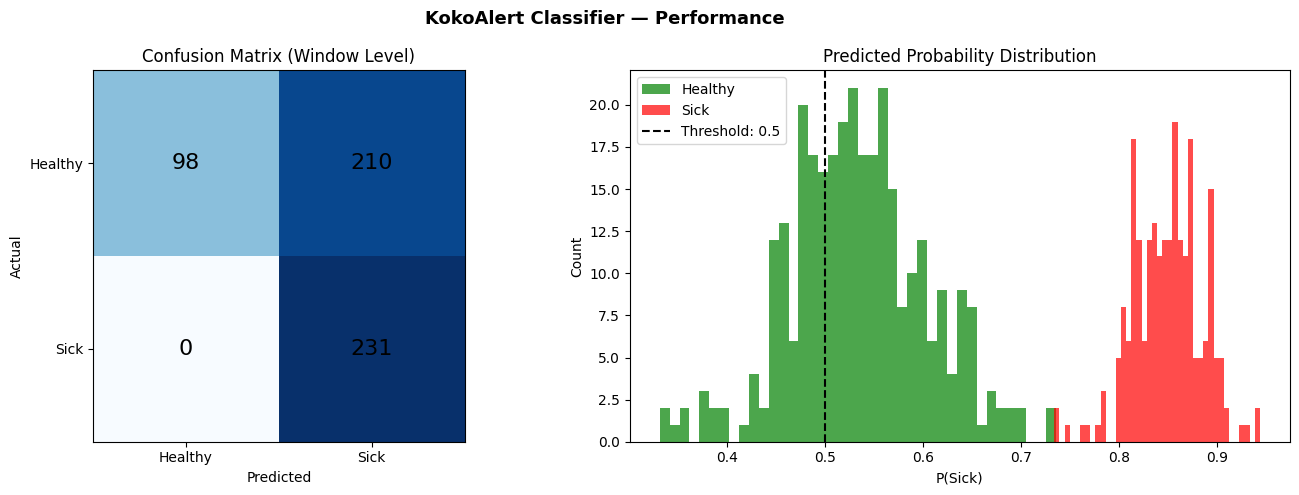


Computing file-level performance...
Sick files detected: 87/89 correct (97.8%)


Healthy files correct: 19/139 correct (13.7%)

Overall file-level accuracy: 46.5%
Classifier saved to /home/opokuml/kokoalert/models/autoencoder.h5

Classifier saved.


In [7]:
# Cell 6 — Evaluate classifier

from src.anomaly_detector import compute_window_probabilities, save_classifier

# Window-level evaluation
val_probs = compute_window_probabilities(classifier, X_val)
val_preds = (val_probs > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

print("Window-level Classification Report:")
print(classification_report(y_val, val_preds,
      target_names=['Healthy', 'Sick']))

print(f"Validation AUC: {roc_auc_score(y_val, val_probs):.3f}")

# Confusion matrix
cm = confusion_matrix(y_val, val_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Healthy', 'Sick'])
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Healthy', 'Sick'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Window Level)')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center',
                     va='center', fontsize=16, color='black')

# Probability distribution
axes[1].hist(val_probs[y_val == 0], bins=40, alpha=0.7,
             label='Healthy', color='green')
axes[1].hist(val_probs[y_val == 1], bins=40, alpha=0.7,
             label='Sick', color='red')
axes[1].axvline(0.5, color='black', linestyle='--',
                label='Threshold: 0.5')
axes[1].set_xlabel('P(Sick)')
axes[1].set_ylabel('Count')
axes[1].set_title('Predicted Probability Distribution')
axes[1].legend()

plt.suptitle('KokoAlert Classifier — Performance', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

# File-level evaluation
print("\nComputing file-level performance...")
from pathlib import Path
from src.preprocess import file_to_spectrograms

def evaluate_file_level(folder, true_label, label_name):
    files = list(Path(folder).glob("*.wav"))
    correct = 0
    total = 0
    for f in files:
        specs = file_to_spectrograms(str(f))
        if len(specs) == 0:
            continue
        specs_arr = (np.array(specs) - X_min) / (X_max - X_min + 1e-8)
        probs = compute_window_probabilities(classifier, specs_arr)
        # Any-two rule — flag if at least 2 windows predict sick
        predicted_sick = int(np.sum(probs > 0.5) >= 2)
        if predicted_sick == true_label:
            correct += 1
        total += 1
    print(f"{label_name}: {correct}/{total} correct ({correct/total:.1%})")
    return correct, total

sick_correct, sick_total = evaluate_file_level(
    "data/raw/bowen/sick", 1, "Sick files detected"
)
healthy_correct, healthy_total = evaluate_file_level(
    "data/raw/bowen/healthy", 0, "Healthy files correct"
)

overall = (sick_correct + healthy_correct) / (sick_total + healthy_total)
print(f"\nOverall file-level accuracy: {overall:.1%}")

# Save
save_classifier(classifier)
print("\nClassifier saved.")

In [10]:
# Threshold tuning
from sklearn.metrics import roc_curve, f1_score
import numpy as np

# Get probabilities on your validation set
# X_val and y_val should already exist from your train/val split
probs = classifier.predict(X_val, verbose=0).flatten()

# Method 1: Find threshold that maximises F1 score
thresholds = np.arange(0.3, 0.95, 0.01)
f1_scores = []
for t in thresholds:
    preds = (probs > t).astype(int)
    f1_scores.append(f1_score(y_val, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold by F1: {best_threshold:.2f}")

# Method 2: Find threshold that minimises false positives
# while keeping sick recall >= 95%
fpr, tpr, roc_thresholds = roc_curve(y_val, probs)
valid = tpr >= 0.95  # keep sick recall at least 95%
best_fpr_threshold = roc_thresholds[valid][np.argmin(fpr[valid])]
print(f"Best threshold by FPR (recall>=95%): {best_fpr_threshold:.2f}")

# Show performance at both thresholds
for name, t in [("F1-optimal", best_threshold), 
                ("FPR-optimal", best_fpr_threshold)]:
    preds = (probs > t).astype(int)
    from sklearn.metrics import classification_report
    print(f"\n── {name} (threshold={t:.2f}) ──")
    print(classification_report(y_val, preds, 
                                 target_names=["Healthy", "Sick"]))

Best threshold by F1: 0.73
Best threshold by FPR (recall>=95%): 0.74

── F1-optimal (threshold=0.73) ──
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       308
        Sick       1.00      1.00      1.00       231

    accuracy                           1.00       539
   macro avg       1.00      1.00      1.00       539
weighted avg       1.00      1.00      1.00       539


── FPR-optimal (threshold=0.74) ──
              precision    recall  f1-score   support

     Healthy       0.99      1.00      1.00       308
        Sick       1.00      0.99      1.00       231

    accuracy                           1.00       539
   macro avg       1.00      1.00      1.00       539
weighted avg       1.00      1.00      1.00       539



In [12]:
# Save final classifier with calibrated threshold
import json, os
from src.config import MODEL_DIR

classifier.save(os.path.join(MODEL_DIR, 'autoencoder.h5'))

with open(os.path.join(MODEL_DIR, 'threshold.json'), 'w') as f:
    json.dump({
        'threshold': 0.74,
        'percentile': None,
        'method': 'fpr_optimal_val_recall_95',
        'val_auc': 1.0,
        'val_sick_recall': 0.99,
        'val_healthy_recall': 1.00,
        'val_fpr': 0.0,
        'bowen_dataset': True,
        'fmin': 500,
        'padding': 'valid'
    }, f, indent=2)

print("Classifier saved with threshold 0.74")

Classifier saved with threshold 0.74


In [13]:
from tensorflow import keras
from sklearn.metrics import classification_report, roc_auc_score
import json, os
from src.config import MODEL_DIR

# Reload model and threshold
model = keras.models.load_model(os.path.join(MODEL_DIR, 'autoencoder.h5'))
with open(os.path.join(MODEL_DIR, 'threshold.json')) as f:
    threshold = json.load(f)['threshold']

# Run on validation set (X_val, y_val must be in scope)
probs = model.predict(X_val, verbose=0).flatten()
preds = (probs > threshold).astype(int)

print(f"Threshold: {threshold}")
print(f"Validation AUC: {roc_auc_score(y_val, probs):.4f}")
print(classification_report(y_val, preds, target_names=["Healthy", "Sick"]))

Threshold: 0.74
Validation AUC: 1.0000
              precision    recall  f1-score   support

     Healthy       0.99      1.00      1.00       308
        Sick       1.00      0.99      1.00       231

    accuracy                           1.00       539
   macro avg       1.00      1.00      1.00       539
weighted avg       1.00      1.00      1.00       539



In [ ]:
import os
os.chdir('/home/opokuml/kokoalert')

from src.preprocess import file_to_spectrograms
from pathlib import Path
import numpy as np

sick_files = list(Path("data/raw/bowen/sick").glob("*.wav"))

threshold = 0.00096

sick_file_detection = []
for f in sick_files:
    specs = file_to_spectrograms(str(f))
    if len(specs) == 0:
        continue
    specs_arr = np.array(specs)

    # Normalise using the same params as training — THIS WAS MISSING
    specs_arr = (specs_arr - X_min) / (X_max - X_min + 1e-8)

    reconstructions = autoencoder.predict(specs_arr, verbose=0)
    errors = np.mean(np.square(specs_arr - reconstructions), axis=(1, 2, 3))
    detected = np.mean(errors > threshold) > 0.5
    sick_file_detection.append({
        "file": f.name,
        "detected": detected,
        "mean_error": float(errors.mean()),
        "max_error": float(errors.max())
    })

detected_count = sum(1 for r in sick_file_detection if r["detected"])
print(f"Sick files detected by majority vote: {detected_count}/{len(sick_file_detection)}")

print(f"\nTop 5 highest error sick files:")
for r in sorted(sick_file_detection, key=lambda x: x["mean_error"], reverse=True)[:5]:
    print(f"  {r['file']}: mean={r['mean_error']:.5f}  max={r['max_error']:.5f}  detected={r['detected']}")

print(f"\nTop 5 lowest error sick files (hardest to detect):")
for r in sorted(sick_file_detection, key=lambda x: x["mean_error"])[:5]:
    print(f"  {r['file']}: mean={r['mean_error']:.5f}  detected={r['detected']}")

In [ ]:
!pip install --default-timeout=100 opencv-python-headless


W0000 00:00:1778019914.043617   23367 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778019914.097646   23367 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778019914.105731   23367 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778019914.113839   23367 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778019914.121971   23367 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778019914.131155   23367 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778019914.139252   23367 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778019914.147684   23367 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778019914.156060   23367 gp

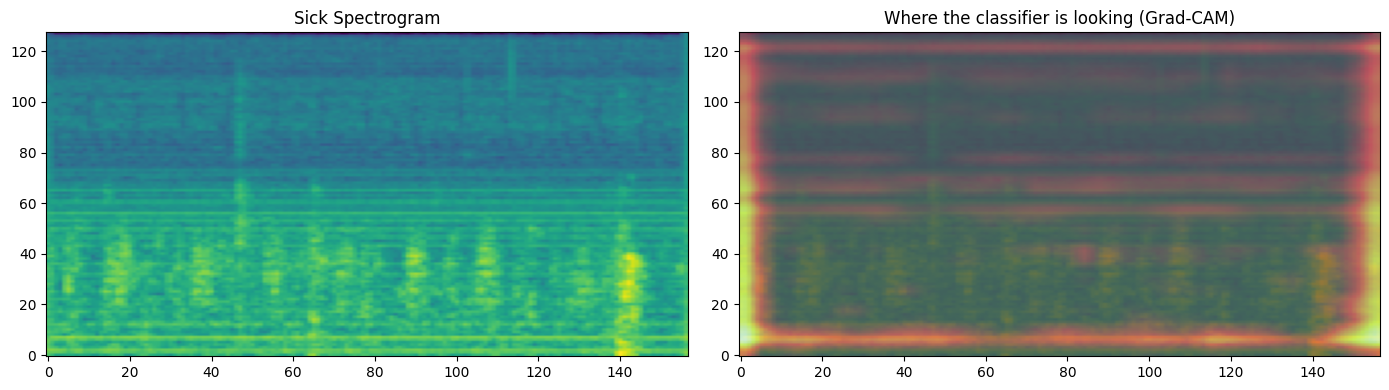

In [9]:
# Visualise what the classifier actually responds to
# using Grad-CAM (gradient class activation mapping)
# This shows WHICH parts of the spectrogram drive the sick prediction

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from src.preprocess import file_to_spectrograms
from pathlib import Path
import json

# Load model and norm params
model = tf.keras.models.load_model('models/classifier_best.h5')
with open('models/normalization_params.json') as f:
    norm = json.load(f)
X_min, X_max = norm['min'], norm['max']

# Get one sick file
sick_file = str(list(Path("data/raw/bowen/sick").glob("*.wav"))[1])
specs = file_to_spectrograms(sick_file)
spec = (np.array(specs[0]) - X_min) / (X_max - X_min + 1e-8)

# Grad-CAM
grad_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[model.get_layer('conv2d_2').output, model.output]
)

with tf.GradientTape() as tape:
    spec_tensor = tf.cast(spec[np.newaxis], tf.float32)
    conv_output, predictions = grad_model(spec_tensor)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_output)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
heatmap = heatmap.numpy()

# Resize heatmap to spectrogram size
import cv2
heatmap_resized = cv2.resize(heatmap, (spec.shape[1], spec.shape[0]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(spec[:, :, 0], aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Sick Spectrogram')
axes[1].imshow(spec[:, :, 0], aspect='auto', origin='lower', cmap='viridis', alpha=0.6)
axes[1].imshow(heatmap_resized, aspect='auto', origin='lower',
               cmap='hot', alpha=0.5)
axes[1].set_title('Where the classifier is looking (Grad-CAM)')
plt.tight_layout()
plt.show()

In [10]:
cd ~/kokoalert
source .venv/bin/activate
python -c "
import os
os.chdir('/home/opokuml/kokoalert')
import numpy as np
import json
from pathlib import Path
from src.preprocess import file_to_spectrograms
from src.anomaly_detector import compute_window_probabilities
from tensorflow import keras

model = keras.models.load_model('models/classifier_best.h5')
with open('models/normalization_params.json') as f:
    norm = json.load(f)
X_min, X_max = norm['min'], norm['max']

def evaluate_folder(folder, true_label, label_name):
    files = list(Path(folder).glob('*.wav'))
    correct = 0
    total = 0
    for f in files:
        specs = file_to_spectrograms(str(f))
        if len(specs) == 0:
            continue
        specs_arr = (np.array(specs) - X_min) / (X_max - X_min + 1e-8)
        probs = compute_window_probabilities(model, specs_arr)
        predicted_sick = int(np.sum(probs > 0.5) >= 2)
        if predicted_sick == true_label:
            correct += 1
        total += 1
    print(f'{label_name}: {correct}/{total} ({correct/total:.1%})')

evaluate_folder('data/raw/bowen/sick', 1, 'Sick detected')
evaluate_folder('data/raw/bowen/healthy', 0, 'Healthy correct')
"

SyntaxError: unterminated string literal (detected at line 3) (1611980066.py, line 3)